<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import pickle

# mount drive
drive.mount('/content/drive')

print("copying zip file from drive to local colab storage")
!cp "/content/drive/MyDrive/ASSIP/archive.zip" "/content/archive.zip"

# unzip it locally using the linux utility
print("unzipping the local file...")
!unzip -q "/content/archive.zip" -d "/content/wesad_data"

# path to the pickle file inside the unzipped folder
data_file_path = '/content/wesad_data/WESAD/S2/S2.pkl'

print("loading subject 2 data...")
with open(data_file_path, 'rb') as file:
    subject_data = pickle.load(file, encoding='latin1')

print("keys found in the file:", subject_data.keys())

Mounted at /content/drive
copying zip file from drive to local colab storage
unzipping the local file...
loading subject 2 data...
keys found in the file: dict_keys(['signal', 'label', 'subject'])


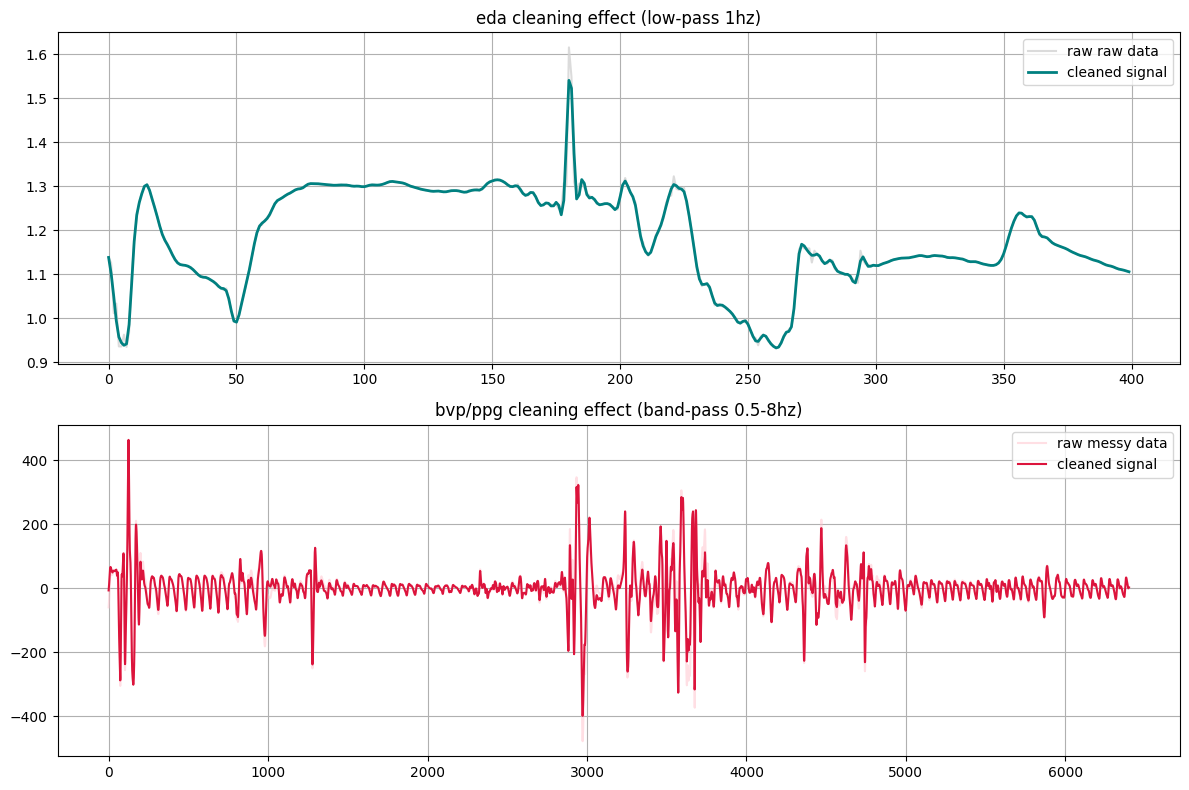

In [2]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def eda_lowpass_filter(data, cutoff=1.0, fs=4.0, order=4): # eda signal lowpass filtering (kills high freq noise above 1 hz)
  nyq = 0.5 * fs # nyquist freq is half of sampling rate
  cutoff_freq = cutoff / nyq
  b, a = butter(order, cutoff_freq, btype='low', analog=False) # building butterworth filter coefficients
  return filtfilt(b, a, data) # eliminates the phase shift caused by running time-series arrays through a butterworth fiter


def bvp_bandpass_filter(data, lowcut=0.5, highcut=8.0, fs=64.0, order=4): # bvp signal bandpass filtering to cut out breathing drift (low) and sensor static (high)
  nyq = 0.5 * fs
  low = lowcut / nyq
  high = highcut / nyq
  b, a = butter(order, [low, high], btype='band', analog=False)
  return filtfilt(b, a, data)

# run raw data throguh filters
raw_eda = subject_data['signal']['wrist']['EDA'].flatten()
raw_bvp = subject_data['signal']['wrist']['BVP'].flatten()

clean_eda = eda_lowpass_filter(raw_eda)
clean_bvp = bvp_bandpass_filter(raw_bvp)

# plot a 100-second window to see difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# build eda plot
ax1.plot(raw_eda[:400], label='raw raw data', color='lightgray', alpha=0.8)
ax1.plot(clean_eda[:400], label='cleaned signal', color='teal', linewidth=2)
ax1.set_title('eda cleaning effect (low-pass 1hz)')
ax1.legend()
ax1.grid(True)

# build bvp plot
ax2.plot(raw_bvp[:6400], label='raw messy data', color='pink', alpha=0.5)
ax2.plot(clean_bvp[:6400], label='cleaned signal', color='crimson', linewidth=1.5)
ax2.set_title('bvp/ppg cleaning effect (band-pass 0.5-8hz)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

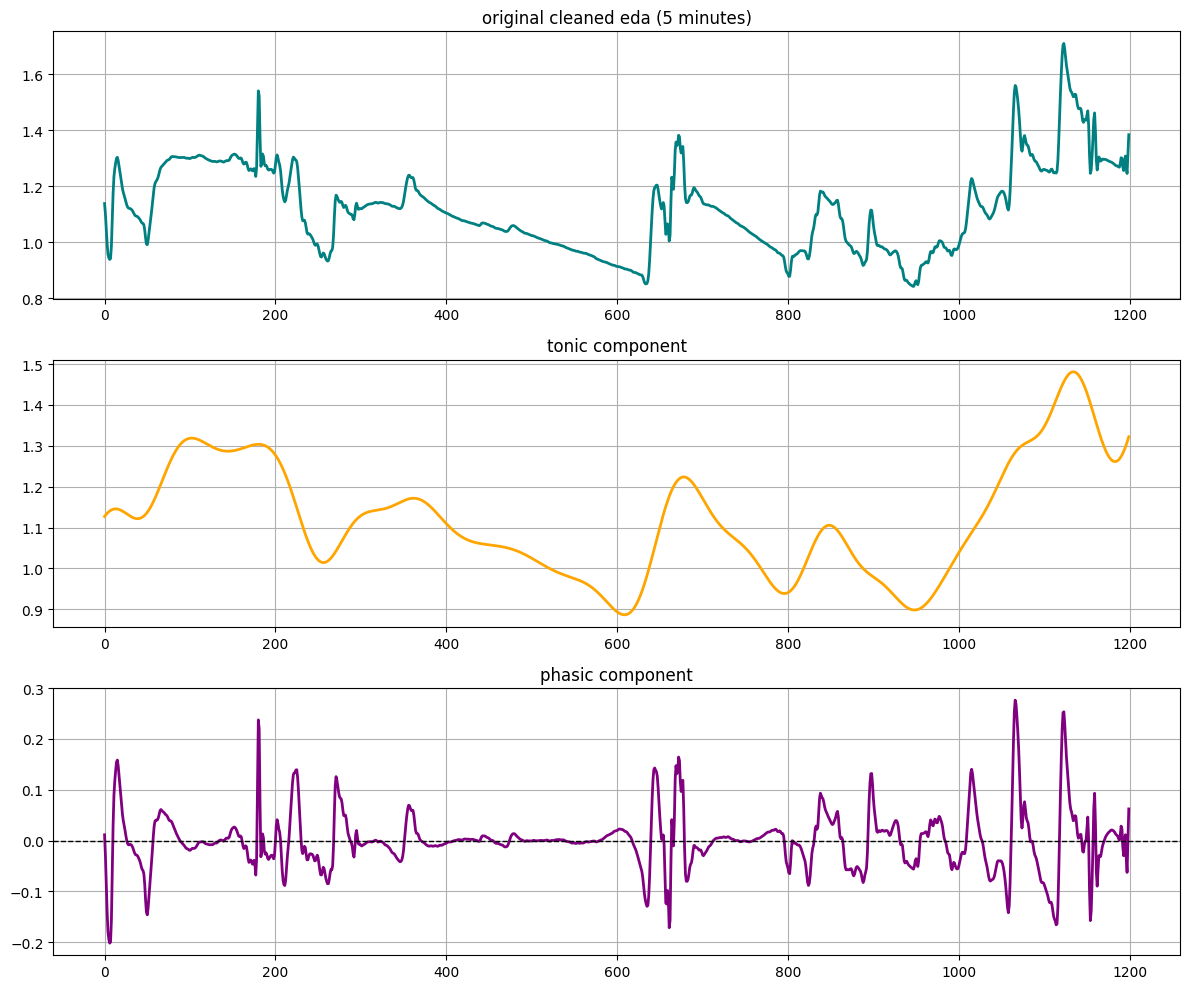

In [3]:
def spit_eda(clean_data, fs=4.0, cutoff=0.05, order=4): # eda decomposition (splitting signals into phasic and tonic) script
  # phasic (scr) - sharp spikes in eda data that represent spikes in sweat (e.g when someone gets a jump scare)
  # tonic (scl) - slow-moving background level of sweat glands; affected by room temp and natural sweat levels
  # highpass filter to catch abrupt spikes (phasic)
  nyq = 0.5 * fs
  normal_cutoff = cutoff / nyq
  b, a = butter(order, normal_cutoff, btype='high', analog=False)
  phasic = filtfilt(b, a, clean_data)
  tonic = clean_data - phasic # tonic is just the whole data - phasic parts
  return phasic, tonic

phasic_eda, tonic_eda = spit_eda(clean_eda) # run the filtered data through the decomposition function

# plot the decomposed signals over a 5-min window
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

window = 1200 # 5 mins * 60 sec * 4 hz = 1200 samples

# the cleaned overall signal
ax1.plot(clean_eda[:window], color='teal', linewidth=2)
ax1.set_title('original cleaned eda (5 minutes)')
ax1.grid(True)

# the tonic component
ax2.plot(tonic_eda[:window], color='orange', linewidth=2)
ax2.set_title('tonic component')
ax2.grid(True)

# the phasic component
ax3.plot(phasic_eda[:window], color='purple', linewidth=2)
ax3.set_title('phasic component')
ax3.axhline(0, color='black', linewidth=1, linestyle='--') # zero line for reference
ax3.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np

# time parameters and standard freqs
window_size = 60 # 60 sec chunks of time
step_size = 30 # window slides by 30 sec each time step

fs_eda = 4
fs_bvp = 64
fs_label = 700

labels = subject_data['label'] # creates lables array from original subject dictionary
total_seconds = len(labels) // fs_label # calculates total time of experiment

print(f"total recording time: {total_seconds} seconds")
print(f"slicing into {window_size}s windows and moving {step_size}s at a time \n")

# lists to hold data
eda_windows = []
bvp_windows = []
window_labels = []

for start in range(0, total_seconds - window_size, step_size):

  # slicing eda data
  eda_start = start * fs_eda
  eda_end = (start + window_size) * fs_eda
  eda_slice = phasic_eda[eda_start:eda_end]

  # slicing bvp data
  bvp_start = start * fs_bvp
  bvp_end = (start + window_size) * fs_bvp
  bvp_slice = clean_bvp[bvp_start:bvp_end]

  # slicing labels and finding the most frequent state
  label_start = start * fs_label
  label_end = (start + window_size) * fs_label
  label_slice = labels[label_start:label_end]

  majority_label = np.bincount(label_slice).argmax() # most common label in each 60 sec time window

  # cleans data by only including baseline (1) or stress (2); transient (0) and amusement (3) is excluded
  if majority_label in [1, 2]:
    eda_windows.append(eda_slice)
    bvp_windows.append(bvp_slice)
    window_labels.append(majority_label)

# convert lists to numpy arrays for ML stuff
eda_windows = np.array(eda_windows)
bvp_windows = np.array(bvp_windows)
window_labels = np.array(window_labels)

print("complete")
print(f"total usable windows extracted: {len(window_labels)}")
print(f"shape of a single eda window: {eda_windows[0].shape} (should be 240)")
print(f"shape of a single bvp window: {bvp_windows[0].shape} (should be 3840)")

# compares stress vs baseline windows
unique, counts = np.unique(window_labels, return_counts=True)
print("\nlabel distribution:")
for val, count in zip(unique, counts):
    state = "baseline" if val == 1 else "stress"
    print(f"{state}: {count} windows")


total recording time: 6079 seconds
slicing into 60s windows and moving 30s at a time 

complete
total usable windows extracted: 59
shape of a single eda window: (240,) (should be 240)
shape of a single bvp window: (3840,) (should be 3840)

label distribution:
baseline: 38 windows
stress: 21 windows
